# 07. 장르 빈도수 피처 생성

- (USER_ID, MOVIE_ID) 중복 제거 — 같은 영화 여러 세션 시청 → 1회로 취급
- 장르별 등장 횟수 / 총 고유 영화 수 = 빈도 비율
- 한 영화에 여러 장르가 있어도 각 장르에 1씩 카운트 (분할 없음)


## 0/1 인코딩 (is_churn_prevented, promotion_yn, repurchase, is_user_verified)

In [11]:
import pandas as pd

In [9]:
features = pd.read_csv('features.csv')

# O/NaN → 1/0, O/N → 1/0
features['is_churn_prevented'] = (features['is_churn_prevented'] == 'O').astype(int)
features['promotion_yn']       = (features['promotion_yn'] == 'O').astype(int)
features['repurchase']         = (features['repurchase'] == 'O').astype(int)
features['is_user_verified']   = (features['is_user_verified'] == 'Y').astype(int)

print('[인코딩 결과]')
for col in ['is_churn_prevented', 'promotion_yn', 'repurchase', 'is_user_verified']:
    vc = features[col].value_counts().sort_index()
    print(f'  {col}: 0={vc.get(0,0):,}  1={vc.get(1,0):,}')

features.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')


[인코딩 결과]
  is_churn_prevented: 0=14,756  1=3,212
  promotion_yn: 0=8,802  1=9,166
  repurchase: 0=6,092  1=11,876
  is_user_verified: 0=4,591  1=13,377
features.csv 저장 완료


## concurrent_streams 결측치 탐색

concurrent_streams 결측치: 73건 / 전체 17,968건

[결측치 행의 product_cd 분포]
            결측수  전체수      비율       표기
product_cd                           
pk_844       48   48  100.0%  48 / 48
pk_118        6    6  100.0%    6 / 6
pk_119        4    4  100.0%    4 / 4
pk_846        4    4  100.0%    4 / 4
pk_1142       3    3  100.0%    3 / 3
pk_847        2    2  100.0%    2 / 2
pk_1079       1    1  100.0%    1 / 1
pk_848        1    1  100.0%    1 / 1
pk_1160       1    1  100.0%    1 / 1
pk_1143       1    1  100.0%    1 / 1
pk_1077       1    1  100.0%    1 / 1
pk_137        1    1  100.0%    1 / 1

[product_cd별 concurrent_streams 고유값 수]
(1이면 해당 product_cd는 값이 완전히 일관됨)
product_cd
pk_1077    0
pk_1079    0
pk_1142    0
pk_1143    0
pk_1160    0
pk_118     0
pk_119     0
pk_137     0
pk_844     0
pk_846     0
pk_847     0
pk_848     0

[amount_krw 구간별 concurrent_streams 최빈값]
            최빈값  결측수   전체수  결측비율         표기
price_band                                 
~1천         1.0    0  9166  0.0%   

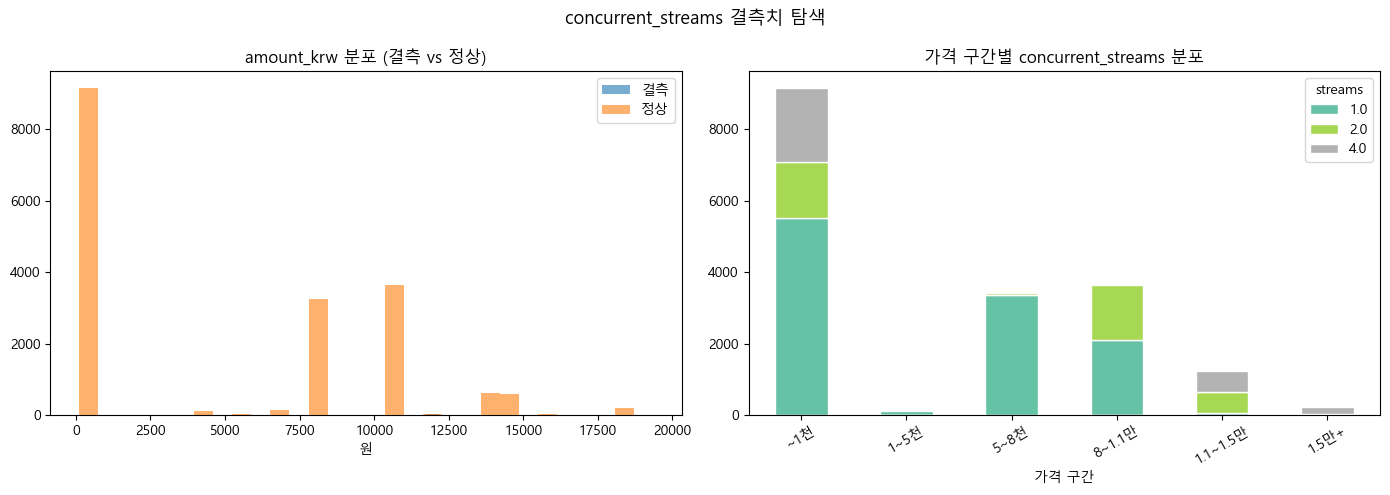

In [15]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

features = pd.read_csv('features.csv')
nan_mask = features['concurrent_streams'].isna()
total_nan = nan_mask.sum()

print(f'concurrent_streams 결측치: {total_nan}건 / 전체 {len(features):,}건')
print()

# ── 1. 결측치 행의 product_cd 분포 ──────────────────────────────
print('=' * 60)
print('[결측치 행의 product_cd 분포]')
print('=' * 60)
nan_prod   = features[nan_mask]['product_cd'].value_counts().rename('결측수')
total_prod = features['product_cd'].value_counts().rename('전체수')
prod_df = pd.concat([nan_prod, total_prod], axis=1).fillna(0)
prod_df['결측수'] = prod_df['결측수'].astype(int)
prod_df = prod_df[prod_df['결측수'] > 0].sort_values('결측수', ascending=False)
prod_df['비율'] = (prod_df['결측수'] / prod_df['전체수'] * 100).round(1).astype(str) + '%'
prod_df['표기'] = prod_df['결측수'].astype(str) + ' / ' + prod_df['전체수'].astype(str)
print(prod_df[['결측수', '전체수', '비율', '표기']].to_string())
print()

# product_cd별 concurrent_streams 값이 얼마나 일관되는지
print('=' * 60)
print('[product_cd별 concurrent_streams 고유값 수]')
print('(1이면 해당 product_cd는 값이 완전히 일관됨)')
print('=' * 60)
consistency = (features.groupby('product_cd')['concurrent_streams']
               .apply(lambda x: x.dropna().nunique())
               .rename('unique_stream_vals'))
nan_prods = prod_df.index.tolist()
print(consistency[consistency.index.isin(nan_prods)].to_string())
print()

# ── 2. amount_krw 구간별 concurrent_streams 분포 ────────────────
print('=' * 60)
print('[amount_krw 구간별 concurrent_streams 최빈값]')
print('=' * 60)
bins   = [0, 1000, 5000, 8000, 11000, 15000, 20000]
labels = ['~1천', '1~5천', '5~8천', '8~1.1만', '1.1~1.5만', '1.5만+']
features['price_band'] = pd.cut(features['amount_krw'], bins=bins, labels=labels)

band_summary = (features[features['concurrent_streams'].notna()]
                .groupby('price_band', observed=True)['concurrent_streams']
                .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
                .rename('최빈값'))
band_count = (features.groupby('price_band', observed=True)['concurrent_streams']
              .apply(lambda x: x.isna().sum()).rename('결측수'))
band_total = features.groupby('price_band', observed=True).size().rename('전체수')
band_df = pd.concat([band_summary, band_count, band_total], axis=1)
band_df['결측비율'] = (band_df['결측수'] / band_df['전체수'] * 100).round(1).astype(str) + '%'
band_df['표기'] = band_df['결측수'].astype(str) + ' / ' + band_df['전체수'].astype(str)
print(band_df[['최빈값', '결측수', '전체수', '결측비율', '표기']].to_string())
print()

# ── 3. 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('concurrent_streams 결측치 탐색', fontsize=13)

features['nan_flag'] = features['concurrent_streams'].isna().map({True: '결측', False: '정상'})
for label, grp in features.groupby('nan_flag'):
    axes[0].hist(grp['amount_krw'], bins=30, alpha=0.6, label=label)
axes[0].set_title('amount_krw 분포 (결측 vs 정상)')
axes[0].set_xlabel('원')
axes[0].legend()

valid = features[features['concurrent_streams'].notna()]
stream_by_band = valid.groupby(['price_band', 'concurrent_streams'], observed=True).size().unstack(fill_value=0)
stream_by_band.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('가격 구간별 concurrent_streams 분포')
axes[1].set_xlabel('가격 구간')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='streams')

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd

features = pd.read_csv('features.csv')

# product_cd별 고유 amount_krw 수 + 금액 목록 확인
price_list = (features.groupby('product_cd')['amount_krw']
              .apply(lambda x: sorted(x.unique().tolist()))
              .rename('금액목록'))
price_count = features.groupby('product_cd')['amount_krw'].nunique().rename('고유금액수')

price_check = pd.concat([price_count, price_list], axis=1).sort_values('고유금액수', ascending=False)
price_check['금액목록'] = price_check['금액목록'].apply(lambda x: ', '.join(f'{int(v):,}' for v in x))

단일 = (price_check['고유금액수'] == 1).sum()
복수 = (price_check['고유금액수'] > 1).sum()
print(f'단일 금액 product_cd: {단일}개 / 복수 금액 product_cd: {복수}개')
print()
print('[고유 금액 수가 2개 이상인 product_cd]')
print(price_check[price_check['고유금액수'] > 1].to_string())
print()
print('[고유 금액 수가 1개인 product_cd (가격 일관)]')
print(price_check[price_check['고유금액수'] == 1].to_string())


단일 금액 product_cd: 40개 / 복수 금액 product_cd: 9개

[고유 금액 수가 2개 이상인 product_cd]
            고유금액수                금액목록
product_cd                           
pk_1487         3   100, 3,950, 7,900
pk_2029         3   100, 3,350, 6,700
pk_2005         3   100, 3,350, 6,700
pk_1488         3  100, 5,450, 10,900
pk_2025         3   100, 3,950, 7,900
pk_2026         3  100, 5,450, 10,900
pk_2027         3  100, 6,950, 13,900
pk_1489         3  100, 6,950, 13,900
pk_121          2        6,210, 6,900

[고유 금액 수가 1개인 product_cd (가격 일관)]
            고유금액수    금액목록
product_cd               
pk_2028         1  13,750
pk_187          1   4,900
pk_1494         1  13,750
pk_1506         1  14,839
pk_1507         1  18,139
pk_1508         1  10,989
pk_1509         1  18,139
pk_1510         1  19,349
pk_188          1   5,900
pk_844          1  12,089
pk_1898         1  11,800
pk_848          1  19,349
pk_847          1  18,139
pk_846          1  14,509
pk_845          1  15,719
pk_2024         1   6,700
pk_1

In [1]:
import pandas as pd

features = pd.read_csv('features.csv')

# product_cd별 최대 금액을 대표 가격으로 매핑
max_price = features.groupby('product_cd')['amount_krw'].max().rename('대표금액')
features = features.join(max_price, on='product_cd')

bins   = [0, 1000, 5000, 8000, 11000, 15000, 20000]
labels = ['~1천', '1~5천', '5~8천', '8~1.1만', '1.1~1.5만', '1.5만+']
features['price_band'] = pd.cut(features['대표금액'], bins=bins, labels=labels)

result = (features[features['concurrent_streams'].notna()]
          .groupby(['price_band', 'concurrent_streams'], observed=True)
          .size()
          .unstack(fill_value=0))

result.columns = [f'streams={int(c)}' for c in result.columns]
result['합계'] = result.sum(axis=1)

print('[product_cd 대표가격(최대) 기준 가격대별 concurrent_streams 분포]')
print(result.to_string())


[product_cd 대표가격(최대) 기준 가격대별 concurrent_streams 분포]
            streams=1  streams=2  streams=4    합계
price_band                                       
1~5천                1          0          0     1
5~8천             9010          0          0  9010
8~1.1만           2099       3153          0  5252
1.1~1.5만           69        591       2731  3391
1.5만+              25         10        206   241


In [2]:
import pandas as pd

features = pd.read_csv('features.csv')

# product_cd별 최대 금액을 대표 가격으로 매핑
max_price = features.groupby('product_cd')['amount_krw'].max().rename('대표금액')
features = features.join(max_price, on='product_cd')

bins   = [0, 1000, 5000, 8000, 11000, 15000, 20000]
labels = ['~1천', '1~5천', '5~8천', '8~1.1만', '1.1~1.5만', '1.5만+']
features['price_band'] = pd.cut(features['대표금액'], bins=bins, labels=labels)

# 가격대별 최고빈도 기준 대체값
fill_map = {
    '~1천'    : 1.0,
    '1~5천'   : 1.0,
    '5~8천'   : 1.0,
    '8~1.1만' : 2.0,
    '1.1~1.5만': 4.0,
    '1.5만+'  : 4.0,
}

before = features['concurrent_streams'].isna().sum()

features['concurrent_streams'] = features.apply(
    lambda row: fill_map.get(str(row['price_band']), 1.0)
    if pd.isna(row['concurrent_streams']) else row['concurrent_streams'],
    axis=1
)

after = features['concurrent_streams'].isna().sum()
print(f'결측치 대체 완료: {before}건 → {after}건 남음')
print()
print('[대체 후 concurrent_streams 분포]')
print(features['concurrent_streams'].value_counts().sort_index())

features = features.drop(columns=['대표금액', 'price_band'])
features.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')


결측치 대체 완료: 73건 → 0건 남음

[대체 후 concurrent_streams 분포]
concurrent_streams
1.0    11214
2.0     3756
4.0     2998
Name: count, dtype: int64
features.csv 저장 완료


# 성별 결측치 처리 (gender=N → 인증 유저 F/M 비율로 대체)

In [ ]:
import pandas as pd
import numpy as np

features = pd.read_csv('features.csv')

# 인증 유저(is_user_verified=1) 기준 F 비율 계산 (N 제외)
verified = features[(features['is_user_verified'] == 1) & (features['gender'] != 'N')]
f_prob = (verified['gender'] == 'F').sum() / len(verified)
print(f'[인증 유저 F/M 비율 (N 제외)]  F={f_prob:.3f}  M={1-f_prob:.3f}')

# gender == 'N' 인 행을 F/M 비율에 따라 랜덤 대체
nan_mask = features['gender'] == 'N'
print(f'대체 전 gender=N 수: {nan_mask.sum()}건')

np.random.seed(42)
features.loc[nan_mask, 'gender'] = np.where(
    np.random.rand(nan_mask.sum()) < f_prob, 'F', 'M'
)

print(f'대체 후 gender=N 수: {(features["gender"] == "N").sum()}건')
print()
print('[대체 후 gender 분포]')
print(features['gender'].value_counts())

features.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')

# 나이 결측치 처리 (인증 유저 age 중앙값으로 대체)

In [4]:
import pandas as pd

features = pd.read_csv('features.csv')

# 인증 유저(is_user_verified=1) 기준 age 중앙값으로 NaN 대체
verified_median = features[features['is_user_verified'] == 1]['age'].median()
print(f'인증 유저 age 중앙값: {verified_median}세')
print(f'대체 전 NaN 수: {features["age"].isna().sum()}건')

features['age'] = features['age'].fillna(verified_median)

print(f'대체 후 NaN 수: {features["age"].isna().sum()}건')
print()
print('[age 기초 통계]')
print(features['age'].describe().round(1))

features.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')


인증 유저 age 중앙값: 30.0세
대체 전 NaN 수: 155건
대체 후 NaN 수: 0건

[age 기초 통계]
count    17968.0
mean        33.8
std         10.5
min         15.0
25%         25.0
50%         35.0
75%         40.0
max         90.0
Name: age, dtype: float64
features.csv 저장 완료


# 불필요 컬럼 제거 (amount, age_group, genre 중복컬럼)

In [ ]:
import pandas as pd

features = pd.read_csv('features.csv', encoding='utf-8-sig')
print(f'정제 전: {features.shape}')

# amount    → amount_krw 로 대체 (USD 결제자는 달러 금액 그대로라 비교 불가)
# age_group → age 로 이미 수치화됨 (중복)
drop_cols = ['amount', 'age_group']

# genre_*_x, genre_*_y → genre_*(합산본)과 완전 동일 (merge 시 생긴 중복 컬럼)
genre_dups = [c for c in features.columns
              if c.startswith('genre_') and (c.endswith('_x') or c.endswith('_y'))]

all_drop = [c for c in drop_cols + genre_dups if c in features.columns]
features = features.drop(columns=all_drop)

print(f'제거 ({len(all_drop)}개): amount, age_group + genre_*_x/y {len(genre_dups)}개')
print(f'정제 후: {features.shape}')

features.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')

# 범주형 인코딩 (gender → 0/1, F=0 / M=1)

In [ ]:
import pandas as pd

features = pd.read_csv('features.csv', encoding='utf-8-sig')
print(f'인코딩 전 gender 분포: {features["gender"].value_counts().to_dict()}')

# gender: F=0, M=1
features['gender'] = (features['gender'] == 'M').astype(int)

print(f'인코딩 후 gender 분포: {features["gender"].value_counts().sort_index().to_dict()}')
print(f'  0(F): {(features["gender"]==0).sum():,}  1(M): {(features["gender"]==1).sum():,}')

features.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')